In [2]:
import pandas as pd

In [3]:
def cargar_y_limpiar(path):
    """Carga un CSV y elimina valores nulos o duplicados en el texto."""
    df = pd.read_csv(path)
    inicial = len(df)

    # Eliminar nulos en las columnas clave
    df = df.dropna(subset=['text', 'summary'])
    # Eliminar textos duplicados
    df = df.drop_duplicates(subset=['text'])

    print(f"[{path}] Registros iniciales: {inicial} | Tras limpieza: {len(df)} | Eliminados: {inicial - len(df)}")
    return df

print("Cargando datasets...")
df_train = cargar_y_limpiar('MLSUM_dataset/es_train.csv')
df_val   = cargar_y_limpiar('MLSUM_dataset/es_validation.csv')
df_test  = cargar_y_limpiar('MLSUM_dataset/es_test.csv')

Cargando datasets...
[MLSUM_dataset/es_train.csv] Registros iniciales: 266367 | Tras limpieza: 262852 | Eliminados: 3515
[MLSUM_dataset/es_validation.csv] Registros iniciales: 10358 | Tras limpieza: 10146 | Eliminados: 212
[MLSUM_dataset/es_test.csv] Registros iniciales: 13920 | Tras limpieza: 13679 | Eliminados: 241


# Proceso Extractivo con TextRank

Vamos a generar los resúmenes utilizando enfoques puramente extractivos. La extracción consiste en seleccionar las oraciones más relevantes del texto original sin generar vocabulario nuevo.

## 1. Preparación del Entorno y Datos
Para optimizar los tiempos de computación, extraeremos una muestra representativa de 500 noticias de nuestro conjunto de test. Además, cargaremos el modelo de lenguaje de `spaCy`, el cual utilizaremos exclusivamente para tokenizar los textos en oraciones gramaticalmente correctas.

In [6]:
import spacy
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import spacy.cli
spacy.cli.download("es_core_news_md")

✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [14]:
# Extraemos 500 noticias aleatorias del test set que ya está en memoria
df_experimento = df_test.sample(n=500, random_state=42).reset_index(drop=True)
print(f"Subset creado con {len(df_experimento)} noticias.")

# Carga del modelo de spaCy 'es_core_news_md' cargado para la segmentación de oraciones
nlp = spacy.load("es_core_news_md")

Subset creado con 500 noticias.


## 2. Definición del Algoritmo TextRank

TextRank es un algoritmo basado en grafos, inspirado en el PageRank de Google. Su funcionamiento en este proyecto es el siguiente:
1. Divide el texto en oraciones.
2. Convierte cada oración en un vector matemático utilizando **TF-IDF**.
3. Calcula la similitud del coseno entre todas las oraciones para crear un grafo.
4. Aplica el algoritmo de centralidad para puntuar las oraciones más conectadas/relevantes.
5. Extrae las *N* mejores oraciones y las reordena cronológicamente para mantener la cohesión del texto.

In [15]:
def resumir_textrank(texto, num_frases=3):
    # 1. Separar en frases usando spaCy (descartamos frases muy cortas)
    doc = nlp(str(texto))
    frases = [sent.text.strip() for sent in doc.sents if len(sent.text.split()) > 4]

    if len(frases) <= num_frases:
        return " ".join(frases)

    # 2. Convertir frases a vectores usando TF-IDF
    vectorizer = TfidfVectorizer(stop_words=list(nlp.Defaults.stop_words))
    vectores_frases = vectorizer.fit_transform(frases)

    # 3. Calcular matriz de similitud y aplicar el algoritmo de grafos
    matriz_similitud = cosine_similarity(vectores_frases)
    grafo = nx.from_numpy_array(matriz_similitud)
    puntuaciones = nx.pagerank(grafo)

    # 4. Ordenar las frases por su puntuación de importancia
    frases_ordenadas = sorted(((puntuaciones[i], s) for i, s in enumerate(frases)), reverse=True)
    mejores_frases = frases_ordenadas[:num_frases]

    # 5. Reordenar las frases ganadoras cronológicamente
    indices_mejores = [frases.index(f[1]) for f in mejores_frases]
    indices_mejores.sort()

    return " ".join([frases[i] for i in indices_mejores])

## 3. Ejecución de Modelos y Guardado

A continuación, aplicamos nuestros dos *baselines* sobre las 500 noticias de prueba:
* **Lead-3:** Un método heurístico clásico en periodismo que simplemente extrae las tres primeras oraciones (basado en la estructura de pirámide invertida).
* **TextRank:** Nuestro algoritmo de grafos.

Finalmente, guardaremos los resultados en un CSV para su posterior evaluación automatizada (con métricas como ROUGE) en el cuaderno final del proyecto.

In [16]:
# En primer lugar realizamos la prueba con Lead-3 para usarla como referencia a la hora de medir nuestro modelo
print("Generando resúmenes con Lead-3 ...")
def lead_3(texto):
    frases = [sent.text.strip() for sent in nlp(str(texto)).sents]
    return " ".join(frases[:3])

df_experimento['resumen_lead3'] = df_experimento['text'].apply(lead_3)

print("Generando resúmenes con TextRank ...")
df_experimento['resumen_textrank'] = df_experimento['text'].apply(lambda x: resumir_textrank(x, num_frases=3))

df_experimento.to_csv("resultados_extractivos.csv", index=False)
print("Resultados guardados en 'resultados_extractivos.csv'")

Generando resúmenes con Lead-3 ...
Generando resúmenes con TextRank ...
Resultados guardados en 'resultados_extractivos.csv'


# Evaluación de Modelos Extractivos

En este cuaderno vamos a evaluar cuantitativamente el rendimiento de nuestros dos enfoques extractivos: **Lead-3** y **TextRank**.

Para ello, utilizaremos **ROUGE** (Recall-Oriented Understudy for Gisting Evaluation), que es la métrica estándar en la industria para tareas de resumen de texto. ROUGE evalúa la calidad de un resumen automático comparándolo con resúmenes escritos por humanos (nuestra columna de referencia).

Nos centraremos en las puntuaciones F1 de:
* **ROUGE-1:** Coincidencia de unigramas (palabras individuales).
* **ROUGE-2:** Coincidencia de bigramas (pares de palabras). Evalúa la fluidez.
* **ROUGE-L:** Secuencia común más larga (Longest Common Subsequence). Evalúa la estructura general de la oración.

In [11]:
# Librería oficial de Hugging Face para evaluación
!pip install evaluate rouge_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.3 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=22043bc7b11e990302bd186af31fa6a1b40aa333edad77c993a1adbac77f2ec6
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


## 1. Carga de Datos y Configuración de Métricas

Comenzamos cargando el dataset que contiene las noticias originales, los resúmenes humanos de referencia y las predicciones generadas por Lead-3 y TextRank en el cuaderno anterior. Además, inicializamos el objeto evaluador de Hugging Face.

In [17]:
import evaluate

# Cargamos el motor de ROUGE
rouge = evaluate.load("rouge")

print("Evaluando Lead-3...")
results_lead3 = rouge.compute(
    predictions=df_experimento['resumen_lead3'],
    references=df_experimento['summary']
)

print("Evaluando TextRank...")
results_textrank = rouge.compute(
    predictions=df_experimento['resumen_textrank'],
    references=df_experimento['summary']
)

df_metricas = pd.DataFrame([results_lead3, results_textrank], index=['Lead-3', 'TextRank'])

print("\nResultados numéricos (F1-Score):")
display(df_metricas)

Evaluando Lead-3...
Evaluando TextRank...

Resultados numéricos (F1-Score):


,rouge1,rouge2,rougeL,rougeLsum
Lead-3,0.207535,0.065767,0.149188,0.149216
TextRank,0.191051,0.061946,0.138689,0.138702


### Análisis de Resultados Extractivos

Tras evaluar ambos baselines con las métricas ROUGE, observamos un fenómeno clásico en la sumarización de noticias: **el baseline heurístico (Lead-3) supera sistemáticamente al algoritmo basado en grafos (TextRank)**.

Analizando las métricas (F1-Score):
* **ROUGE-1 (Unigramas):** Lead-3 alcanza un ~20.7%, frente al ~19.1% de TextRank. Esto indica que extraer las primeras frases captura un mayor volumen de vocabulario clave idéntico al usado por los periodistas humanos en sus resúmenes.
* **ROUGE-2 y ROUGE-L:** Lead-3 también domina en la captura de bigramas (6.5% vs 6.1%) y en la estructura secuencial (14.9% vs 13.8%).

**¿Por qué ocurre esto?**
Este resultado valida la hipótesis de la **"Pirámide Invertida"** en el sesgo periodístico. En el dataset MLSUM, las noticias están redactadas de forma que la información más vital (el qué, quién, cuándo y dónde) se concentra obligatoriamente en el primer párrafo (*Lead*).

TextRank, al buscar la centralidad matemática a través de todo el documento, tiende a rescatar oraciones del ecuador o final de la noticia que, aunque matemáticamente conectadas con el resto del texto, aportan detalles secundarios que los humanos no incluyen en un resumen conciso.

Por tanto, nuestro reto para el modelo generativo (mT5) será demostrar si una Inteligencia Artificial es capaz de superar la altísima densidad informativa que ya nos regalan de por sí las tres primeras frases de una noticia.

## 5. Visualización y Conclusiones del Enfoque Extractivo

Para comprender mejor qué modelo ha funcionado mejor en nuestra muestra de 500 noticias, visualizaremos los resultados en un gráfico de barras. Finalmente, guardaremos el dataframe completo con los resúmenes para tener un registro de este experimento.

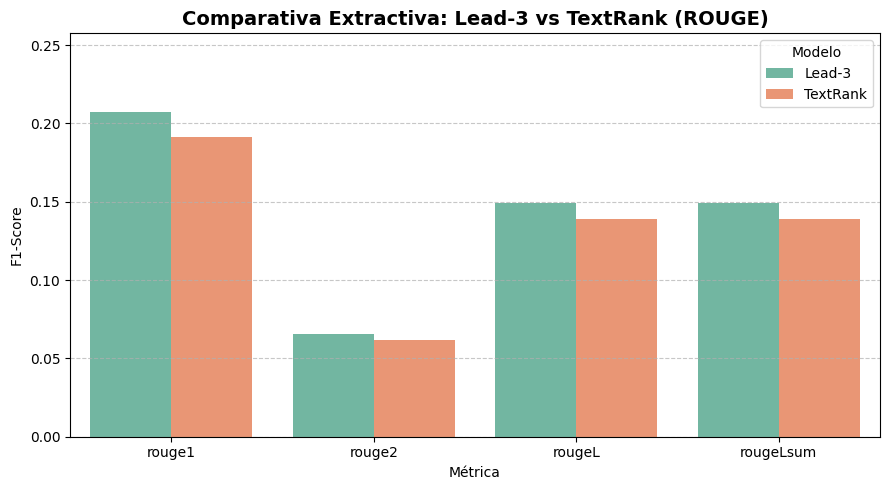

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparamos los datos para que Seaborn pueda graficarlos fácilmente
df_plot = df_metricas.reset_index().rename(columns={'index': 'Modelo'})
df_plot = df_plot.melt(id_vars='Modelo', var_name='Métrica', value_name='Puntuación (F1)')

plt.figure(figsize=(9, 5))
sns.barplot(data=df_plot, x='Métrica', y='Puntuación (F1)', hue='Modelo', palette='Set2')

plt.title('Comparativa Extractiva: Lead-3 vs TextRank (ROUGE)', fontsize=14, fontweight='bold')
plt.ylim(0, max(df_plot['Puntuación (F1)']) + 0.05) # Ajuste automático del eje Y
plt.ylabel('F1-Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()


plt.savefig("metricas_extractivas.png", dpi=300)
plt.show()

df_experimento.to_csv("resultados_extractivos_validados.csv", index=False)